### Importar librerias y cargue de datos

In [158]:
import pandas as pd
from scipy import stats as st
import datetime as dt
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [159]:
hypotheses = pd.read_csv("/datasets/hypotheses_us.csv",sep=';')
orders = pd.read_csv("/datasets/orders_us.csv",sep=',')
visits  = pd.read_csv("/datasets/visits_us.csv",sep=',')

### Acceso y preparación de los datos

#### DF hypotheses_us

In [160]:
# Verificación DF
display(hypotheses)

,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


In [161]:
# Información DF
print(hypotheses.describe(),"\n\n\n")
print(hypotheses.info())

           Reach     Impact  Confidence     Effort
count   9.000000   9.000000    9.000000   9.000000
mean    4.777778   4.777778    5.555556   4.888889
std     3.153481   3.192874    3.045944   2.803767
min     1.000000   1.000000    1.000000   1.000000
25%     3.000000   3.000000    3.000000   3.000000
50%     3.000000   3.000000    7.000000   5.000000
75%     8.000000   7.000000    8.000000   6.000000
max    10.000000  10.000000    9.000000  10.000000 



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes
None


#### DF orders

In [162]:
# Verificación DF
display(orders)

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
...,...,...,...,...,...
1192,2662137336,3733762160,2019-08-14,100.8,B
1193,2203539145,370388673,2019-08-14,50.1,A
1194,1807773912,573423106,2019-08-14,165.3,A
1195,1947021204,1614305549,2019-08-14,5.5,A


In [163]:
# Información DF
print(orders.describe(),"\n\n\n")
print(orders.info(),"\n\n\n")
visits["group"].unique()

       transactionId     visitorId       revenue
count   1.197000e+03  1.197000e+03   1197.000000
mean    2.155621e+09  2.165960e+09    131.491646
std     1.229085e+09  1.236014e+09    603.004729
min     1.062393e+06  5.114589e+06      5.000000
25%     1.166776e+09  1.111826e+09     20.800000
50%     2.145194e+09  2.217985e+09     50.200000
75%     3.237740e+09  3.177606e+09    130.400000
max     4.293856e+09  4.283872e+09  19920.400000 



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB
None 





array(['A', 'B'], dtype=object)

#### DF visits

In [164]:
# Verificación DF
display(visits)

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756
...,...,...,...
57,2019-08-27,B,720
58,2019-08-28,B,654
59,2019-08-29,B,531
60,2019-08-30,B,490


In [165]:
# Información DF
print(visits.describe(),"\n\n\n")
print(visits.info(),"\n\n\n")
visits["group"].unique()

           visits
count   62.000000
mean   607.290323
std    114.400560
min    361.000000
25%    534.000000
50%    624.500000
75%    710.500000
max    770.000000 



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB
None 





array(['A', 'B'], dtype=object)

#### Modificar  columnas y tipo de datos.

In [166]:
visits.rename(columns={'visits': 'visitors'}, inplace=True)

In [167]:
orders.rename(columns={'transactionId' : 'orderId','visitorId' : 'userId'}, inplace=True)

In [168]:
visits['date'] = visits['date'].map(lambda x: dt.datetime.strptime(x, '%Y-%m-%d'))
orders['date'] = orders['date'].map(lambda x: dt.datetime.strptime(x, '%Y-%m-%d'))

### Exploración y ajustes

In [169]:
visits[visits['group']=='A'].describe()

,visitors
count,31.000000
mean,604.387097
std,112.396227
min,361.000000
25%,541.000000
50%,619.000000
75%,705.000000
max,756.000000


In [170]:
visits[visits['group']=='B'].describe()

,visitors
count,31.000000
mean,610.193548
std,118.156230
min,369.000000
25%,537.000000
50%,654.000000
75%,711.000000
max,770.000000


In [171]:
orders[orders['group']=='A']['revenue'].describe()

count     557.000000
mean      115.897487
std       182.358918
min         5.000000
25%        20.400000
50%        50.100000
75%       130.500000
max      1450.200000
Name: revenue, dtype: float64

In [172]:
orders[orders['group']=='B']['revenue'].describe()

count      640.000000
mean       145.063438
std        806.992326
min          5.100000
25%         24.050000
50%         50.350000
75%        130.225000
max      19920.400000
Name: revenue, dtype: float64

In [173]:
userIdA = orders[orders['group'] == 'A']['userId'].drop_duplicates()
userIdB = orders[orders['group'] == 'B']['userId'].drop_duplicates()

In [174]:
userIdAFiltered = orders[orders['group'] == 'A']['userId'].drop_duplicates()
userIdBFiltered = orders[orders['group'] == 'B']['userId'].drop_duplicates()

### 1. Priorizar la hipótesis

* Aplicar el framework ICE para priorizar hipótesis. Ordenarlas en orden descendente de prioridad.
* Aplicar el framework RICE para priorizar hipótesis. Ordenarlas en orden descendente de prioridad.
* Mostrar cómo cambia la priorización de hipótesis cuando utilizas RICE en lugar de ICE. Proporcionar una explicación de los cambios.

In [175]:
hypotheses['ICE'] = (hypotheses['Impact']*hypotheses['Confidence'])/hypotheses['Effort']

hypotheses['RICE'] = (hypotheses['Reach']*hypotheses['Impact']*hypotheses['Confidence'])/hypotheses['Effort']

hypotheses


,Hypothesis,Reach,Impact,Confidence,Effort,ICE,RICE
0,Add two new channels for attracting traffic. T...,3,10,8,6,13.333333,40.0
1,Launch your own delivery service. This will sh...,2,5,4,10,2.000000,4.0
2,Add product recommendation blocks to the store...,8,3,7,3,7.000000,56.0
3,Change the category structure. This will incre...,8,3,3,8,1.125000,9.0
4,Change the background color on the main page. ...,3,1,1,1,1.000000,3.0
5,Add a customer review page. This will increase...,3,2,2,3,1.333333,4.0
6,Show banners with current offers and sales on ...,5,3,8,3,8.000000,40.0
7,Add a subscription form to all the main pages....,10,7,8,5,11.200000,112.0
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.200000,16.2


In [176]:
display(hypotheses[['Hypothesis','ICE']].sort_values(by='ICE', ascending=False))
display(hypotheses[['Hypothesis','RICE']].sort_values(by='RICE', ascending=False))

,Hypothesis,ICE
8,Launch a promotion that gives users discounts ...,16.200000
0,Add two new channels for attracting traffic. T...,13.333333
7,Add a subscription form to all the main pages....,11.200000
6,Show banners with current offers and sales on ...,8.000000
2,Add product recommendation blocks to the store...,7.000000
1,Launch your own delivery service. This will sh...,2.000000
5,Add a customer review page. This will increase...,1.333333
3,Change the category structure. This will incre...,1.125000
4,Change the background color on the main page. ...,1.000000


,Hypothesis,RICE
7,Add a subscription form to all the main pages....,112.0
2,Add product recommendation blocks to the store...,56.0
0,Add two new channels for attracting traffic. T...,40.0
6,Show banners with current offers and sales on ...,40.0
8,Launch a promotion that gives users discounts ...,16.2
3,Change the category structure. This will incre...,9.0
1,Launch your own delivery service. This will sh...,4.0
5,Add a customer review page. This will increase...,4.0
4,Change the background color on the main page. ...,3.0


#### **Conclusiones y comentarios:**
Con el método ICE, las 3 principales hipótesis son:

* Hipótesis 9: Lanzar una promoción que ofrezca a los usuarios descuentos en sus cumpleaños.
* Hipótesis 1: Agregar dos nuevos canales para atraer tráfico. Esto traerá un 30% más de usuarios.
* Hipótesis 8: Agregar un formulario de suscripción en todas las páginas principales. Esto ayudará a crear una lista de correos.

Con el método RICE, las 3 principales hipótesis son:
* Hipótesis 8: Agregar un formulario de suscripción en todas las páginas principales. Esto ayudará a crear una lista de correos.
* Hipótesis 3: Agregar bloques de recomendaciones de productos en el sitio de la tienda. Esto aumentará la conversión y el tamaño promedio de compra.
* Hipótesis 1: Agregar dos nuevos canales para atraer tráfico. Esto traerá un 30% más de usuarios.

### 2. Análisis del test A/B

1. Representa gráficamente el ingreso acumulado por grupo. Haz conclusiones y conjeturas.
2. Representa gráficamente el tamaño de pedido promedio acumulado por grupo. Haz conclusiones y conjeturas.
3. Representa gráficamente la diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparación con el grupo A. Haz conclusiones y conjeturas.
4. Calcula la tasa de conversión de cada grupo como la relación entre los pedidos y el número de visitas de cada día. Representa gráficamente las tasas de conversión diarias de los dos grupos y describe la diferencia. Saca conclusiones y haz conjeturas.
5. Traza un gráfico de dispersión del número de pedidos por usuario. Haz conclusiones y conjeturas.
6. Calcula los percentiles 95 y 99 del número de pedidos por usuario. Define el punto en el cual un punto de datos se convierte en una anomalía.
7. Traza un gráfico de dispersión de los precios de los pedidos. Haz conclusiones y conjeturas.
8. Calcula los percentiles 95 y 99 de los precios de los pedidos. Define el punto en el cual un punto de datos se convierte en una anomalía.
9. Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto. Haz conclusiones y conjeturas.
10. Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto. Haz conclusiones y conjeturas.
11. Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados. Haz conclusiones y conjeturas.
12. Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados. Haz conclusiones y conjeturas.
13. Toma una decisión basada en los resultados de la prueba. Las decisiones posibles son:
    * Parar la prueba, considerar a uno de los grupos como líder.
    * Parar la prueba, concluir que no hay diferencia entre los grupos.
    * Continuar la prueba.

#### 1. Representa gráficamente el ingreso acumulado por grupo.

In [177]:
#Creación del conjunto de combinaciones únicas de fecha y grupo
datesGroups = (orders[['date','group']].drop_duplicates()) 
datesGroups.head(10)

,date,group
0,2019-08-15,B
2,2019-08-15,A
45,2019-08-16,A
47,2019-08-16,B
55,2019-08-01,A
66,2019-08-01,B
85,2019-08-22,B
86,2019-08-22,A
124,2019-08-17,A
125,2019-08-17,B


In [178]:
#gregación acumulada de pedidos por grupo y fecha
ordersAggregated = (
    datesGroups
    .apply(lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])]
    .agg({'date' : 'max', 
          'group' : 'max', 
          'orderId' : pd.Series.nunique, 
          'userId' : pd.Series.nunique, 
          'revenue' : 'sum'}), 
           axis=1)
    .sort_values(by=['date','group'])
)

ordersAggregated.head(10)

,date,group,orderId,userId,revenue
55,2019-08-01,A,24,20,2356.8
66,2019-08-01,B,21,20,1620.0
175,2019-08-02,A,44,38,3860.3
173,2019-08-02,B,45,43,4243.8
291,2019-08-03,A,68,62,5675.5
310,2019-08-03,B,61,59,6050.6
499,2019-08-04,A,84,77,6822.1
498,2019-08-04,B,78,75,7767.9
698,2019-08-05,A,109,100,8810.2
699,2019-08-05,B,101,98,9262.9


In [179]:
#Agregación acumulada de visitas por grupo y fecha
visitsAggregated = (
    datesGroups
    .apply(lambda x: visits[np.logical_and(visits['date'] <= x['date'], visits['group'] == x['group'])]
    .agg({'date' : 'max', 
          'group' : 'max', 
          'visitors' : 'sum'}), 
           axis=1)
    .sort_values(by=['date','group'])
)

visitsAggregated.head(10)

,date,group,visitors
55,2019-08-01,A,719
66,2019-08-01,B,713
175,2019-08-02,A,1338
173,2019-08-02,B,1294
291,2019-08-03,A,1845
310,2019-08-03,B,1803
499,2019-08-04,A,2562
498,2019-08-04,B,2573
698,2019-08-05,A,3318
699,2019-08-05,B,3280


In [180]:
#Unificación de datos acumulados de pedidos y visitas

cumulativeData = (
    ordersAggregated
    .merge(visitsAggregated, 
           left_on=['date', 'group'], 
           right_on=['date', 'group'])
)
cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']

cumulativeData.head(10)

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,24,20,2356.8,719
1,2019-08-01,B,21,20,1620.0,713
2,2019-08-02,A,44,38,3860.3,1338
3,2019-08-02,B,45,43,4243.8,1294
4,2019-08-03,A,68,62,5675.5,1845
5,2019-08-03,B,61,59,6050.6,1803
6,2019-08-04,A,84,77,6822.1,2562
7,2019-08-04,B,78,75,7767.9,2573
8,2019-08-05,A,109,100,8810.2,3318
9,2019-08-05,B,101,98,9262.9,3280


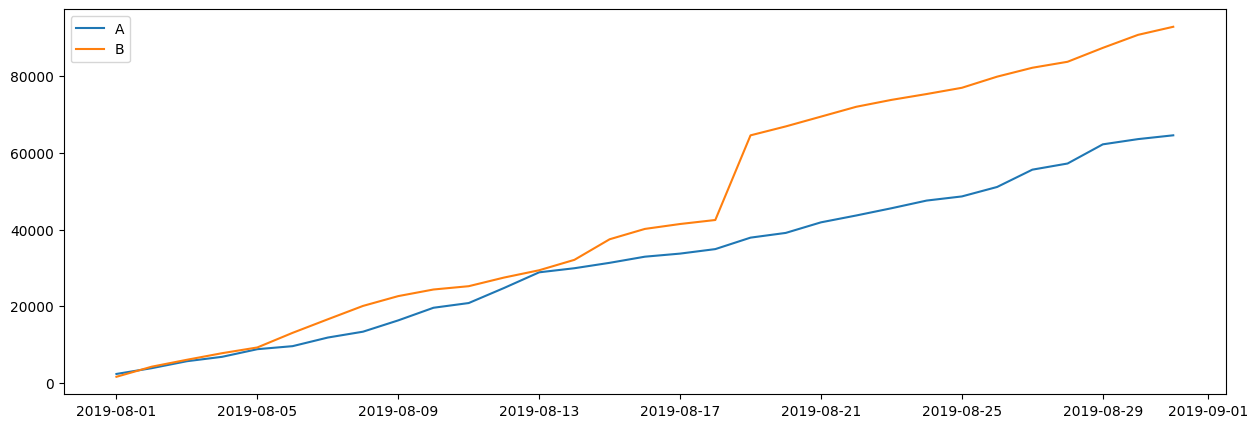

In [181]:
#Visualización del ingreso acumulado por grupo (A/B)
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]

plt.figure(figsize=(15, 5))
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='B')
plt.legend() 

##### **Conclusiones y comentarios:**
Para ambos grupos, se puede observar que los ingresos siguieron aumentando durante la prueba lo cual puede ser considerado una buena señal.


Es importante resaltar que el grupo **B**, registra un pico de ingresos en 18 de agosto del 2019. ¿Qué pasó durante y después de esa fecha? Se podría inferir qun aumento repentino en el número de pedidos o presencia de pedidos con un alto valor monetario.

#### 2. Representa gráficamente el tamaño de pedido promedio acumulado por grupo.

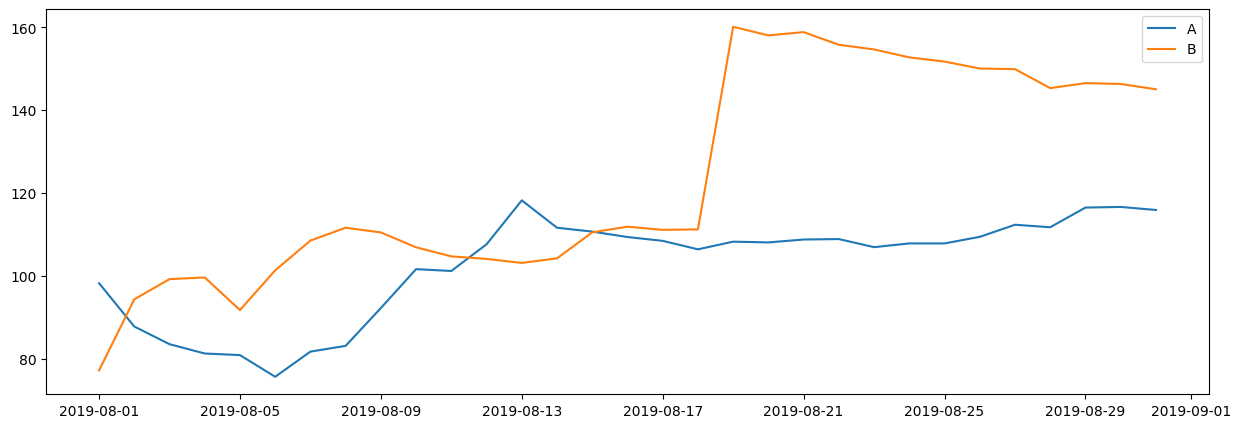

In [182]:
#Visualización del ingreso promedio por pedido acumulado en los grupos (A/B)
plt.figure(figsize=(15, 5))
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue']/cumulativeRevenueA['orders'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'], label='B')
plt.legend()

##### **Conclusiones y comentarios:**
Se observa el mismo pico para el 18 de agosto del 2019 para el grupo **B**. El valor promedio del monto de las compras se muestra estable en la recta final de la prueba.

#### Representar gráficamente la diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparación con el grupo A.

In [183]:
#Fusión de los ingresos acumulados de los grupos (A/B) por fecha
mergedCumulativeRevenue = cumulativeRevenueA.merge(cumulativeRevenueB, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

mergedCumulativeRevenue.head(10)


,date,revenueA,ordersA,revenueB,ordersB
0,2019-08-01,2356.8,24,1620.0,21
1,2019-08-02,3860.3,44,4243.8,45
2,2019-08-03,5675.5,68,6050.6,61
3,2019-08-04,6822.1,84,7767.9,78
4,2019-08-05,8810.2,109,9262.9,101
5,2019-08-06,9600.0,127,13069.3,129
6,2019-08-07,11842.9,145,16600.8,153
7,2019-08-08,13373.3,161,20088.6,180
8,2019-08-09,16320.4,177,22646.7,205
9,2019-08-10,19608.6,193,24367.1,228


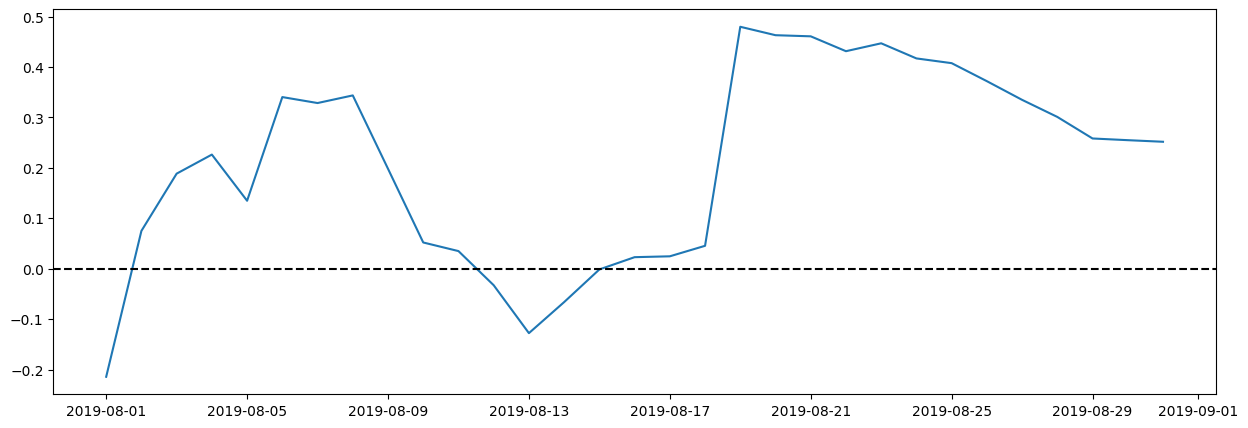

In [184]:
# Visualización de la diferencia acumulada en ingreso promedio por pedido entre los grupos (A/B)
plt.figure(figsize=(15, 5))
plt.plot(mergedCumulativeRevenue['date'], (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])/(mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])-1)

plt.axhline(y=0, color='black', linestyle='--')

##### **Conclusiones y comentarios:**
Se aprecia varios puntos donde la diferencia entre los segmentos, aumenta drásticamente. Esto puede indicar la presencia de órdenes grandes y valores atípicos.

#### Calcular la tasa de conversión de cada grupo como la relación entre los pedidos y el número de visitas de cada día. Representar gráficamente las tasas de conversión diarias de los dos grupos y describe la diferencia.

(18109.0, 18139.0, 0.0, 0.05)

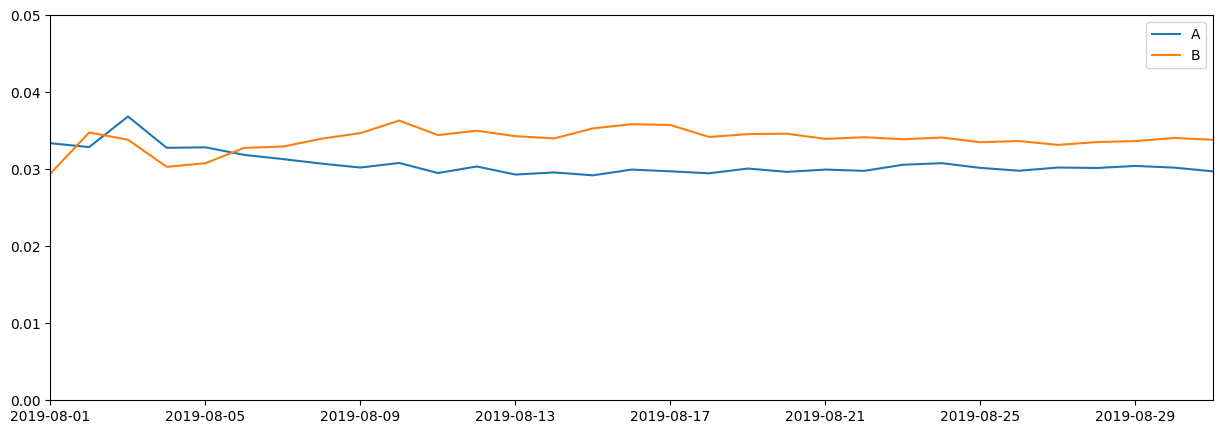

In [185]:
#Análisis de % de conversión acumulada por grupo (A/B)
cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors']
cumulativeDataA = cumulativeData[cumulativeData['group']=='A']
cumulativeDataB = cumulativeData[cumulativeData['group']=='B']

plt.figure(figsize=(15, 5))
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B')
plt.legend()

plt.axis([pd.to_datetime('2019-08-01'), pd.to_datetime('2019-08-31'), 0, 0.05])

##### **Conclusiones y comentarios:**
El grupo **B** tiene una mejor conversión acumulada, lo que indica que la prueba tuvo un impacto positivo en la cantidad de visitantes que realizan una compra.

Además, es importante resaltar que se define una cierta simetría en las pruebas

In [186]:
#Análisis de % de conversión acumulada por grupo (A/B) por fecha
mergedCumulativeConversions = cumulativeDataA[['date','conversion']].merge(cumulativeDataB[['date','conversion']], left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

mergedCumulativeConversions.head(10)

,date,conversionA,conversionB
0,2019-08-01,0.033380,0.029453
1,2019-08-02,0.032885,0.034776
2,2019-08-03,0.036856,0.033833
3,2019-08-04,0.032787,0.030315
4,2019-08-05,0.032851,0.030793
5,2019-08-06,0.031870,0.032783
6,2019-08-07,0.031324,0.032946
7,2019-08-08,0.030731,0.033975
8,2019-08-09,0.030225,0.034699
9,2019-08-10,0.030821,0.036323


(18109.0, 18139.0, -0.5, 0.5)

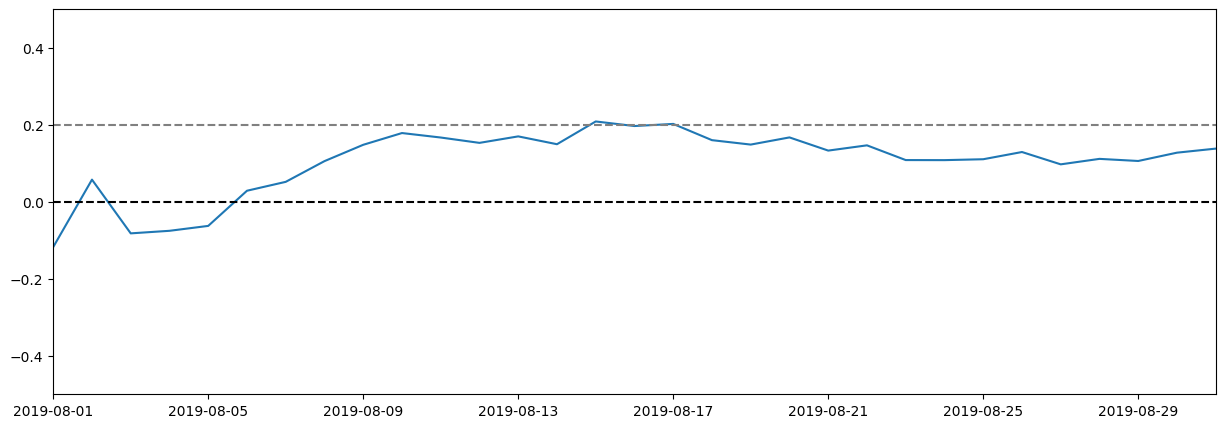

In [187]:
#Visualización de la diferencia relativa en la tasa de conversión entre los grupos (A/B)
plt.figure(figsize=(15, 5))
plt.plot(mergedCumulativeConversions['date'], mergedCumulativeConversions['conversionB']/mergedCumulativeConversions['conversionA']-1)

plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.2, color='grey', linestyle='--')
plt.axis([pd.to_datetime('2019-08-01'), pd.to_datetime('2019-08-31'), -0.5, 0.5])

##### **Conclusiones y comentarios:**

El grupo **B** logra una conversión acumulada consistentemente superior a la del grupo **A** durante todo el experimento.
Esto sugiere que la modificación implementada en el grupo **B** tuvo un impacto positivo real en el comportamiento de los usuarios.

#### Trazar gráfico de dispersión del número de pedidos por usuario.

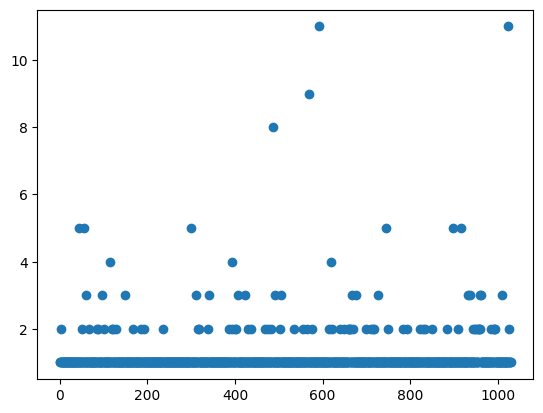

In [188]:
#Distribución del número de pedidos por usuario
ordersByUsers = (
    orders
    .drop(['group', 'revenue','date'], axis=1)
    .groupby('userId', as_index=False)
    .agg({'orderId': pd.Series.nunique})
)
ordersByUsers.columns = ['userId', 'orders']

x_values = pd.Series(range(0,len(ordersByUsers)))
plt.scatter(x_values, ordersByUsers['orders']) 

##### **Conclusiones y comentarios:**

1. Claramente sepuede observar que, la mayoría de los usuarios, solo realizó un pedido.
2. Existe un grupo reducido de usuarios con múltiples pedidos (Muestran un comportamiento de 2 o más pedidos).
3. La distribución está altamente sesgada (Valores están cerca a 1).

#### Calcular los percentiles 95 y 99 del número de pedidos por usuario.

In [189]:
print(np.percentile(ordersByUsers['orders'], [95, 99])) 

[2. 4.]


##### **Conclusiones y comentarios:**
El número de usuarios que realizaron más de 2 pedidos, no superó el 5%.

Esto significa que se puede establecer el límite inferior (2) como filtro de pedidos que presentan "anomalias"

#### Trazar gráfico de dispersión de los precios de los pedidos.

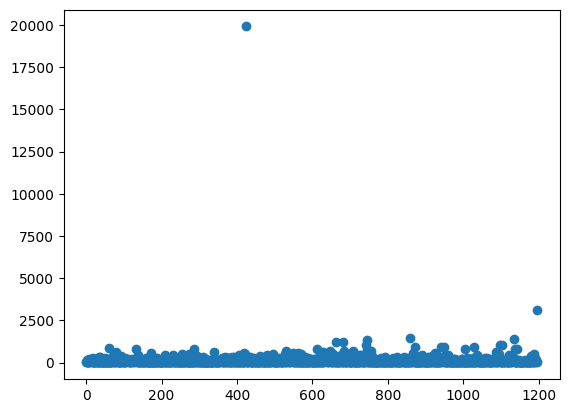

In [190]:
x_values = pd.Series(range(0,len(orders['revenue'])))
plt.scatter(x_values, orders['revenue']) 

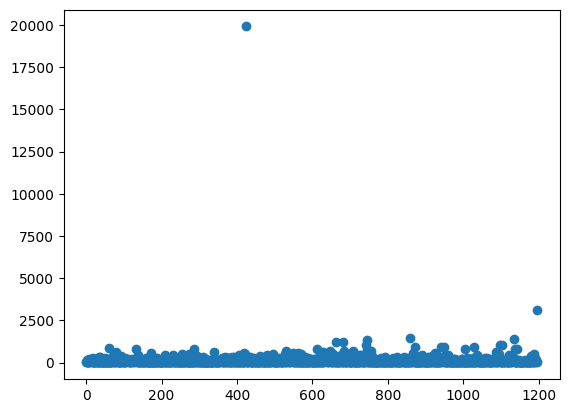

In [191]:
x_values = pd.Series(range(0,len(orders['revenue'])))
plt.scatter(x_values, orders['revenue']) 

##### **Conclusiones y comentarios:**
1. La mayoria de los pedidos, muestran precios bajos.
2. Existen outliers, en especial un par que se muestran más alejados del resto.
3. La distribución muestra que hay muchos pedidos pequeñoy y muy pocos con valores altos.

#### Calcular los percentiles 95 y 99 de los precios de los pedidos.

In [192]:
print(np.percentile(orders['revenue'], [95, 99]))

[435.54  900.904]


##### **Conclusiones y comentarios:**
El 95% de los pedidos, tiene un valor menor a $435.54 USD.

#### Encontrar la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto.

In [193]:
#Cálculo del número de pedidos por usuario en cada grupo (A/B)
ordersByUsersA = orders[orders['group']=='A'].groupby('userId', as_index=False).agg({'orderId' : pd.Series.nunique})
ordersByUsersA.columns = ['userId', 'orders']

ordersByUsersB = orders[orders['group']=='B'].groupby('userId', as_index=False).agg({'orderId' : pd.Series.nunique})
ordersByUsersB.columns = ['userId', 'orders']

In [194]:
#Creación de la muestra del grupo A incluyendo usuarios sin pedidos
sampleA = (
    pd.concat([ordersByUsersA['orders'],
               pd.Series(0, 
                         index=np.arange(
                             visits[visits['group']=='A']['visitors'].sum() 
                             - len(ordersByUsersA['orders'])
                         ), 
                         name='orders')],
              axis=0
             )
)

In [195]:
#Creación de la muestra del grupo B incluyendo usuarios sin pedidos
sampleB = (
    pd.concat([ordersByUsersB['orders'],
               pd.Series(0, 
                         index=np.arange(
                             visits[visits['group']=='B']['visitors'].sum() 
                             - len(ordersByUsersB['orders'])
                         ), 
                         name='orders')],
              axis=0
             )
)

In [196]:
#Prueba estadística de diferencia en las tasas de conversión entre grupos (A/B)
alpha = 0.05
results1 = st.mannwhitneyu(sampleA, sampleB)
print('p-value: ', results1.pvalue.round(3))

if (results1.pvalue < alpha):
    print("Se rechaza la hipótesis nula: la diferencia fue estadísticamente significativa.")
else:
    print("No se puede rechazar la hipótesis nula: no podemos concluir si hay alguna diferencia significativa")
    
print('Ganancia de conversión relativa para el grupo B: ','{0:.3f}'.format(sampleB.mean() / sampleA.mean() - 1))


p-value:  0.017
Se rechaza la hipótesis nula: la diferencia fue estadísticamente significativa.
Ganancia de conversión relativa para el grupo B:  0.138


##### **Conclusiones y comentarios:**
Basado en los datos en bruto, se encuentra que existe una diferencia significativa entre los grupos A y B.

Se aprecia un p-value = 0.017 (Inferior a 0.05), por lo tanto, se rechaza la hipotesis nula ya que existe una diferencia estadística significativa en la tasa de conversión entre los grupos.

El grupo **B**, presenta una ganancia de conversión relativa del 13.8%

#### Encontrar la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto. 

In [197]:
#Prueba estadística de diferencia en los ingresos entre los grupos (A/B)
alpha = 0.05
results2 = st.mannwhitneyu(orders[orders['group']=='A']['revenue'], orders[orders['group']=='B']['revenue'])
print('p-value: ', results2.pvalue.round(3))

if (results2.pvalue < alpha):
    print("Se rechaza la hipótesis nula: la diferencia fue estadísticamente significativa.")
else:
    print("No se puede rechazar la hipótesis nula: no podemos concluir si hay alguna diferencia significativa.")
    
print('Ganancia de conversión relativa para el grupo B: ','{0:.3f}'.format(orders[orders['group']=='B']['revenue'].mean()/orders[orders['group']=='A']['revenue'].mean()-1))



p-value:  0.692
No se puede rechazar la hipótesis nula: no podemos concluir si hay alguna diferencia significativa.
Ganancia de conversión relativa para el grupo B:  0.252


##### **Conclusiones y comentarios:**
p-value es mucho mayor que 0.05, por lo tanto no podemos rechazar la hipótesis nula y concluir que el tamaño promedio de los pedidos entre los grupos es diferente.

Sin embargo, el tamaño promedio de los pedidos para el grupo B, es mucho mayor que para el del grupo A.

#### Encontrar la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados. 

In [198]:
#Identificación de usuarios con múltiples pedidos (outliers)
usersWithManyOrders = (
    pd.concat(
        [ordersByUsersA[ordersByUsersA['orders'] > 1]['userId'], ordersByUsersB[ordersByUsersB['orders'] > 1]['userId']], 
        axis = 0)
)

print('Usuarios con un pedido superior al 95% de los datos:',len(usersWithManyOrders), 'users')

Usuarios con un pedido superior al 95% de los datos: 64 users


In [199]:
#Identificación de usuarios con pedidos de alto valor (por encima del percentil 95)
usersWithExpensiveOrders = orders[orders['revenue'] > 414]['userId']

print('Usuarios con un tamaño de pedido superior al 95% de los datos:',len(usersWithExpensiveOrders),'users')

Usuarios con un tamaño de pedido superior al 95% de los datos: 66 users


In [206]:
#Identificación y consolidación de usuarios anómalos (pedidos múltiples o de alto valor)
abnormalUsers = (
    pd
    .concat([usersWithManyOrders, usersWithExpensiveOrders], 
            axis = 0)
    .drop_duplicates()
    .sort_values()
)

print('En total, se cuenta con un total de', len(abnormalUsers), 'usuarios tipo "outlier"')

En total, se cuenta con un total de 115 usuarios tipo "outlier"


In [201]:
#Creación de muestra filtrada del grupo A (excluyendo outliers)
sampleAFiltered = pd.concat(
    [
        ordersByUsersA[
            np.logical_not(ordersByUsersA['userId'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                visits[visits['group'] == 'A']['visitors'].sum()
                - len(ordersByUsersA['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

In [202]:
#Creación de muestra filtrada del grupo B (excluyendo outliers)
sampleBFiltered = pd.concat(
    [
        ordersByUsersB[
            np.logical_not(ordersByUsersB['userId'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                visits[visits['group'] == 'B']['visitors'].sum()
                - len(ordersByUsersB['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

In [203]:
#Prueba estadística Mann–Whitney en datos filtrados
results3 = st.mannwhitneyu(sampleAFiltered, sampleBFiltered)
print('p-value: ', results3.pvalue.round(3))

if (results3.pvalue < alpha):
    print("Se rechaza la hipótesis nula: la diferencia fue estadísticamente significativa.")
else:
    print("No se puede rechazar la hipótesis nula: no podemos concluir si hay alguna diferencia significativa.")
    
print('Ganancia de conversión relativa para el grupo B en datos filtrados: ','{0:.3f}'.format(sampleBFiltered.mean() / sampleAFiltered.mean() - 1))


p-value:  0.02
Se rechaza la hipótesis nula: la diferencia fue estadísticamente significativa.
Ganancia de conversión relativa para el grupo B en datos filtrados:  0.162


##### **Conclusiones y comentarios:**
En resumen, se muestra que los resultados no han variado. Sigue existiendo una diferencia significativa entre los grupos A y B.

p-value: 0.02 (Inferior a 0.05), por lo tanto se rechaza la hipótesis nula ya que si existe una diferencia estadítica significativa en la concersión entre los grupos.

La ganancia de conversión relativa para el grupo B es del 16.2%

#### 12. Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados.

In [205]:
# Prueba estadística de diferencia en los ingresos entre los grupos (A/B) con datos filtrados
alpha = 0.05

revenueA_filtered = orders[(orders['group'] == 'A') & (~orders['userId'].isin(abnormalUsers))]['revenue']

revenueB_filtered = orders[(orders['group'] == 'B') & (~orders['userId'].isin(abnormalUsers))]['revenue']

results_revenue_filtered = st.mannwhitneyu(revenueA_filtered, revenueB_filtered)

print('p-value:', results_revenue_filtered.pvalue.round(3))

if results_revenue_filtered.pvalue < alpha:
    print("Se rechaza la hipótesis nula: la diferencia fue estadísticamente significativa.")
else:
    print("No se puede rechazar la hipótesis nula: no podemos concluir si hay alguna diferencia significativa.")

relative_gain = revenueB_filtered.mean() / revenueA_filtered.mean() - 1
print('Ganancia relativa de ingresos para el grupo B en datos filtrados: ', f'{relative_gain:.3f}')

p-value: 0.815
No se puede rechazar la hipótesis nula: no podemos concluir si hay alguna diferencia significativa.
Ganancia relativa de ingresos para el grupo B en datos filtrados:  -0.022


##### **Conclusiones y comentarios:**
En resumen, se muestra que los resultados no evidencian una diferencia entre los grupos A y B.

p-value: 0.815 (superior a 0.05), por lo tanto, no se rechaza la hipótesis nula, lo que indica que no existe una diferencia estadísticamente significativa en los ingresos entre los grupos tras filtrar los datos.

La ganancia relativa de ingresos para el grupo B fue de -2.2%, lo que sugiere que el grupo B obtuvo un rendimiento ligeramente inferior al del grupo A, aunque sin significancia estadística.

#### Toma una decisión basada en los resultados de la prueba. Las decisiones posibles son:
* Parar la prueba, considerar a uno de los grupos como líder.
* Parar la prueba, concluir que no hay diferencia entre los grupos.
* Continuar la prueba. *←←←←*


#### ***CONCLUSIONES FINALES:***
**Conclusiones de la prueba:**
1. Tanto las prueba en los datos brutos, como los filtrados, mostraron diferencias estadísticamente significativas en las conversiones entre los grupos.
2. Para ambos casos, mostraron diferencias estadísticas significativas en el tamaño promedio de los pedidos entre grupos.
3. En los gráficos, se muestran una diferenciua en el tamaño promedio de los pedidos entre grupos. Se indica claramente que los resultados del grupo **B** son superiores con respecto al grupo **A**.

**Partiendo de que la prueba A/B se llevó a cabo para comprobar la hipótesis 3, se concluye:**

* Para aumentar la tasa de conversión y el tamaño promedio de la compra, es ideal agregar bloques de recomendación de productos en el sitio web de la tienda. De está manera se muestra un comportamiento favorable frente a esta opción.

En resumen, se puede concluir con excelente desempeño en la prueba debido a sus resultados en el grupo **B** con respecto al grupo **A**. Esto se traduce en que se debería considerar continuar la prueba para poder obtener más datos y entender el comportamiento durante ese tiempo extra, de esta manera, es posible determinar si es posible sostener el cambio y obtener mejores resultados a futuro.